===== MÉTRICAS OPERACIONAIS =====

MTTR Geral: 47.98 minutos
SLA Compliance: 57.00%

MTTR por Categoria:
category
Hardware Fault         57.125000
Partial Outage         50.125000
Total Outage           49.483871
Link Down              48.013333
Power Failure          44.137931
Weather Impact         42.750000
Configuration Error    41.754098
Name: resolution_time_min, dtype: float64

===== SIMULAÇÃO DE AUTOMAÇÃO =====
Novo MTTR estimado: 40.78 minutos
Redução absoluta: 7.20 minutos
Redução percentual: 15.00%

MTTR por Severidade:
severity
1     26.39375
2     52.10000
3    109.62000
Name: resolution_time_min, dtype: float64

% Violação SLA por Severidade:
severity
1      7.50
2     74.44
3    100.00
Name: sla_breached, dtype: float64


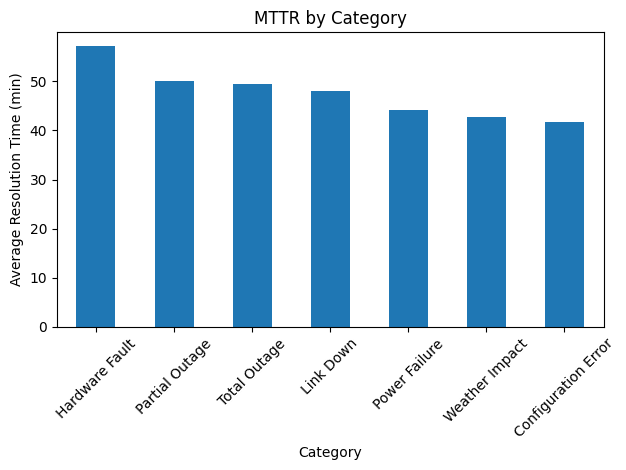

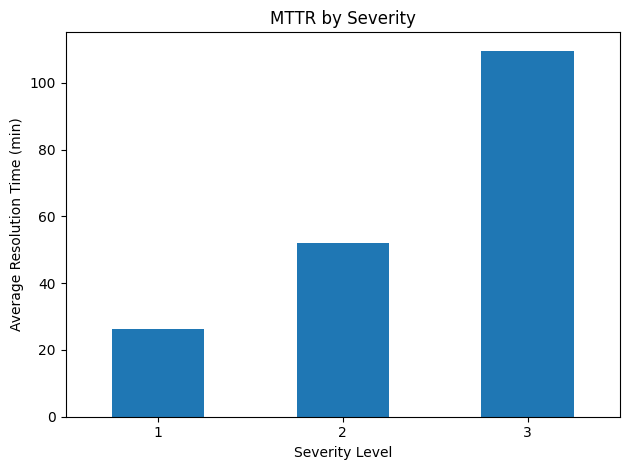

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Carregar dados
# -----------------------------
df = pd.read_csv("../data/raw/sample_incidents.csv")

# -----------------------------
# MTTR Geral
# -----------------------------
mttr_geral = df["resolution_time_min"].mean()

# -----------------------------
# MTTR por Categoria
# -----------------------------
mttr_por_categoria = (
    df.groupby("category")["resolution_time_min"]
    .mean()
    .sort_values(ascending=False)
)

# -----------------------------
# SLA Compliance
# -----------------------------
total_incidentes = len(df)
sla_violacoes = df["sla_breached"].sum()
sla_compliance = 100 * (1 - sla_violacoes / total_incidentes)

# -----------------------------
# Simulação Automação (-15%)
# -----------------------------
df["resolution_time_optimized"] = df["resolution_time_min"] * 0.85
novo_mttr = df["resolution_time_optimized"].mean()

# -----------------------------
# Resultados
# -----------------------------
print("===== MÉTRICAS OPERACIONAIS =====\n")
print(f"MTTR Geral: {mttr_geral:.2f} minutos")
print(f"SLA Compliance: {sla_compliance:.2f}%\n")

print("MTTR por Categoria:")
print(mttr_por_categoria)

print("\n===== SIMULAÇÃO DE AUTOMAÇÃO =====")
print(f"Novo MTTR estimado: {novo_mttr:.2f} minutos")
print(f"Redução absoluta: {mttr_geral - novo_mttr:.2f} minutos")
print(f"Redução percentual: {((mttr_geral - novo_mttr)/mttr_geral)*100:.2f}%")

# -----------------------------
# MTTR por Severidade
# -----------------------------
mttr_por_severidade = (
    df.groupby("severity")["resolution_time_min"]
    .mean()
)

print("\nMTTR por Severidade:")
print(mttr_por_severidade)

# SLA por Severidade
sla_por_severidade = (
    df.groupby("severity")["sla_breached"]
    .mean()
)

print("\n% Violação SLA por Severidade:")
print((sla_por_severidade * 100).round(2))

# MTTR por Categoria
mttr_por_categoria.plot(kind="bar")
plt.title("MTTR by Category")
plt.ylabel("Average Resolution Time (min)")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/mttr_by_category.png")
plt.show()

mttr_por_severidade.plot(kind="bar")
plt.title("MTTR by Severity")
plt.ylabel("Average Resolution Time (min)")
plt.xlabel("Severity Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../docs/mttr_by_severity.png")
plt.show()
